In [19]:
# ==========================================================
# HEART DISEASE PREDICTION USING MACHINE LEARNING
# Final Project - Machine Learning Course
# ==========================================================

# Student: Md Alamgir Shahidullah
# Dataset Source: IEEE DataPort Heart Disease Dataset
# ==========================================================


# ============================================================
# 1. Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

sns.set_style("whitegrid")



In [20]:
# ============================================================
# 2. Load Dataset
# ============================================================

df = pd.read_csv("heart_statlog_cleveland_hungary_final.csv")

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

First 5 rows of dataset:
   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   40    1                2           140          289                    0   
1   49    0                3           160          180                    0   
2   37    1                2           130          283                    0   
3   48    0                4           138          214                    0   
4   54    1                3           150          195                    0   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0            0             172                0      0.0         1       0  
1            0             156                0      1.0         2       1  
2            1              98                0      0.0         1       0  
3            0             108                1      1.5         2       1  
4            0             122                0      0.0         1       0  

Dataset shape:
(1190, 12)


In [21]:
# ============================================================
# 3. Understand Dataset Structure
# ============================================================

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())


Column names:
Index(['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
       'fasting blood sugar', 'resting ecg', 'max heart rate',
       'exercise angina', 'oldpeak', 'ST slope', 'target'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null 

In [22]:
# ============================================================
# 4. Data Cleaning
# ============================================================

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows before removal:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())
print("New dataset shape:", df.shape)


Missing values in each column:
age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

Duplicate rows before removal: 272
Duplicate rows after removal: 0
New dataset shape: (918, 12)


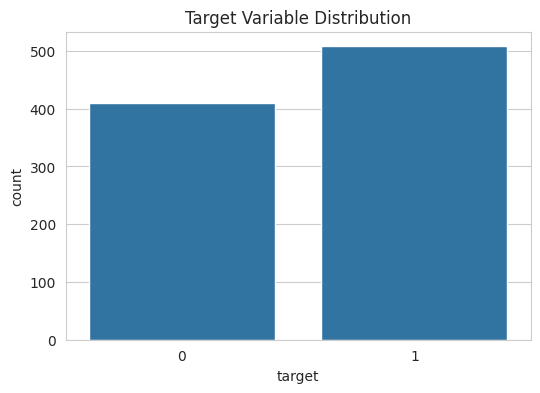


Target counts:
target
1    508
0    410
Name: count, dtype: int64


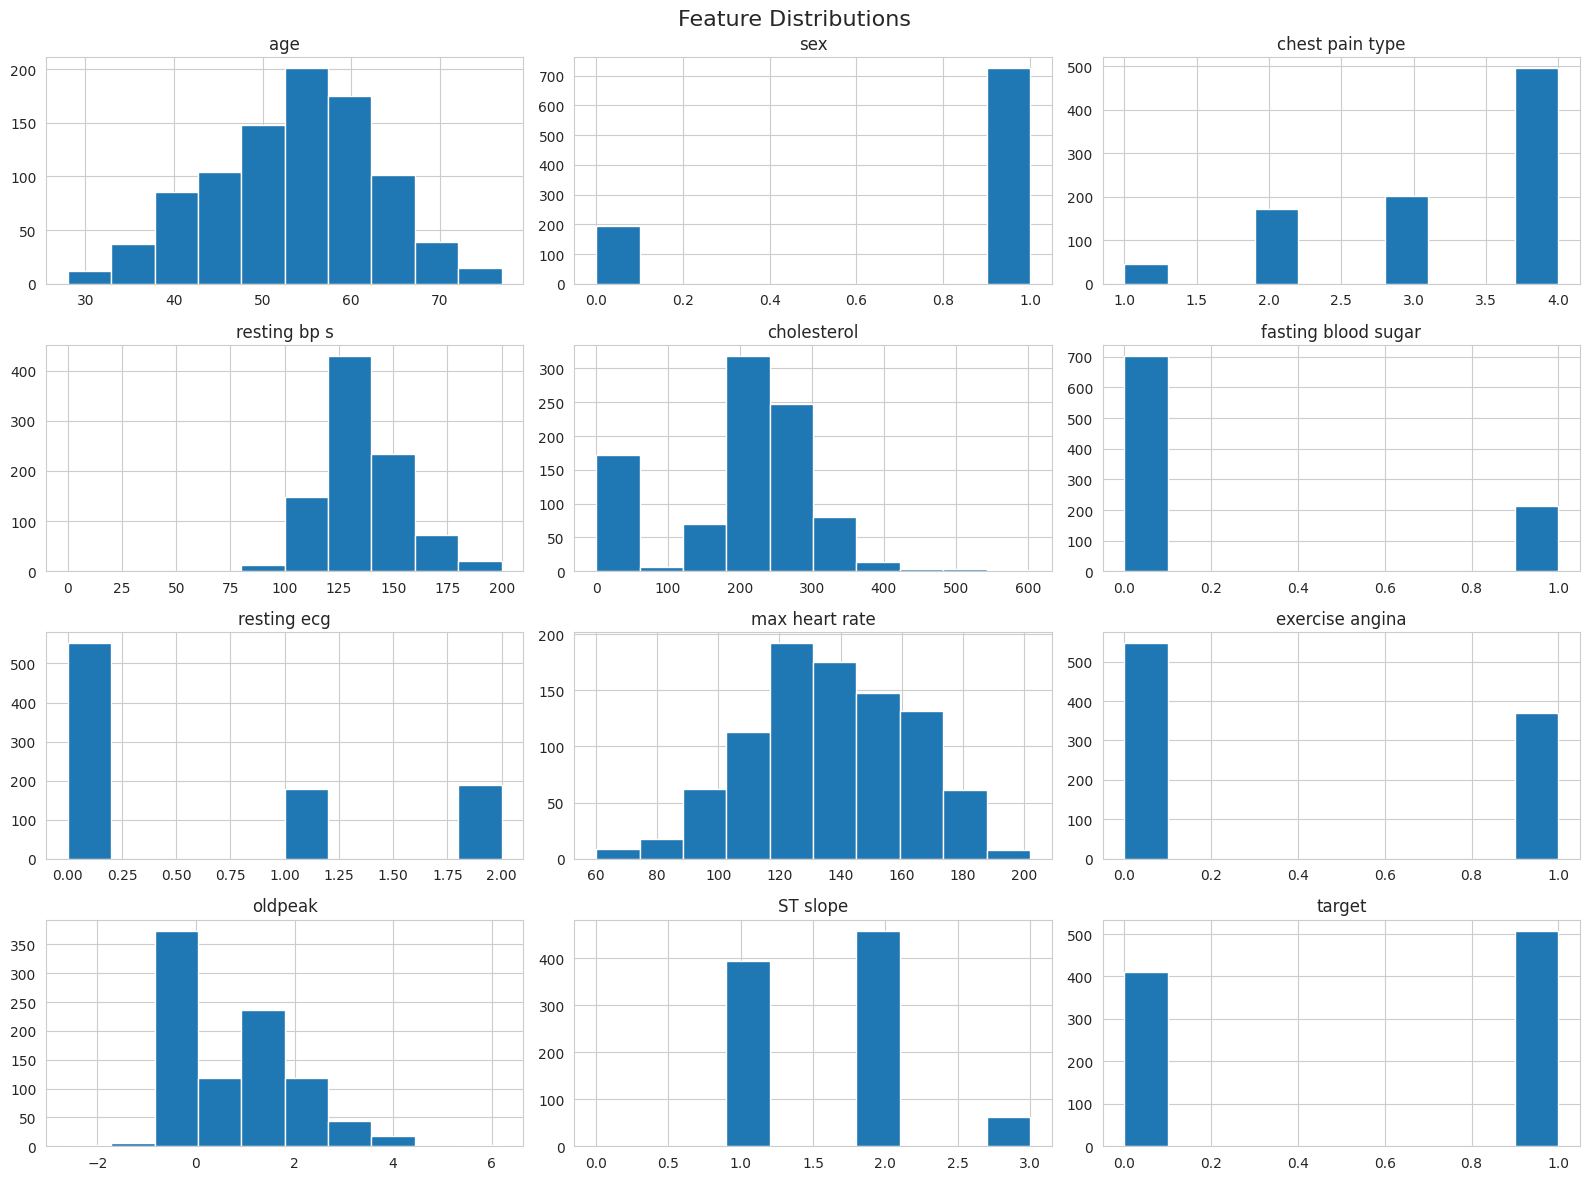

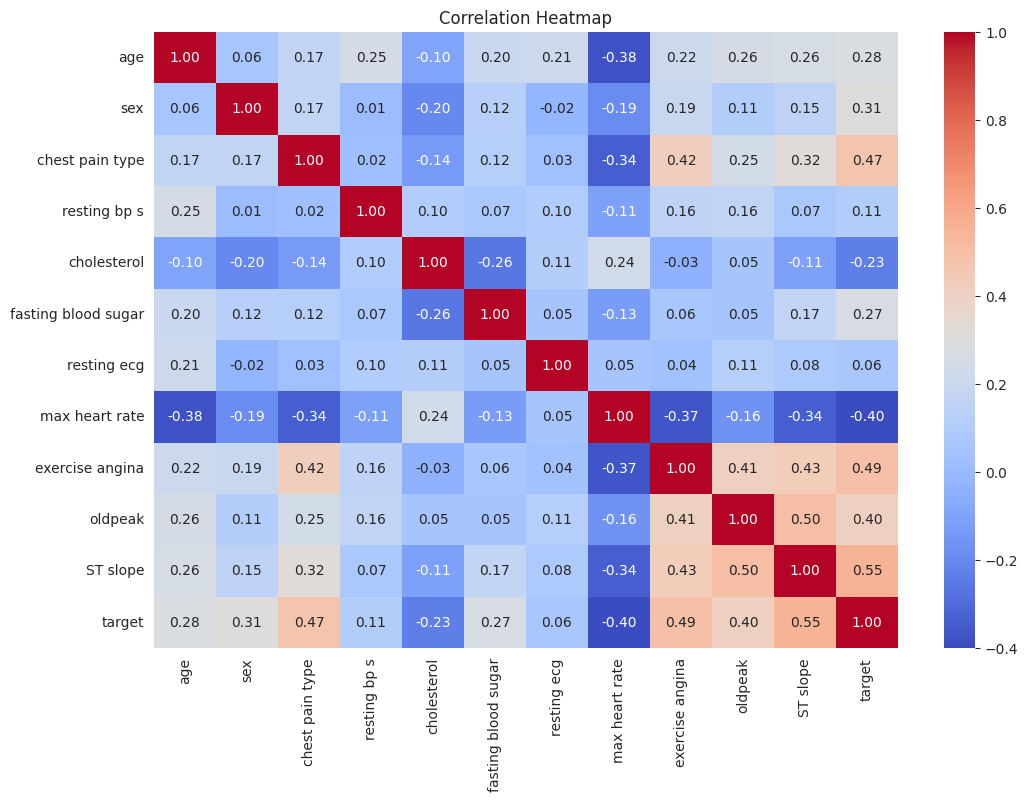

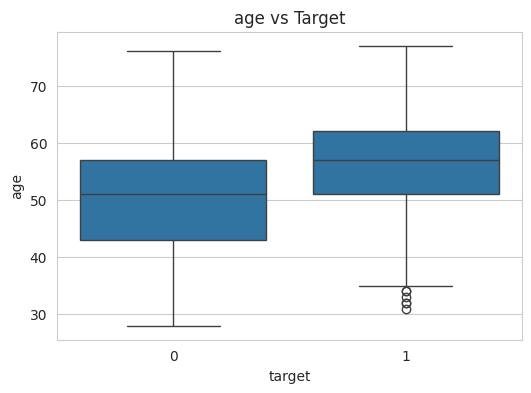

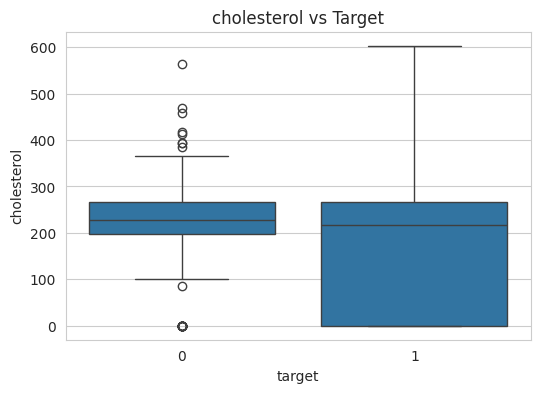

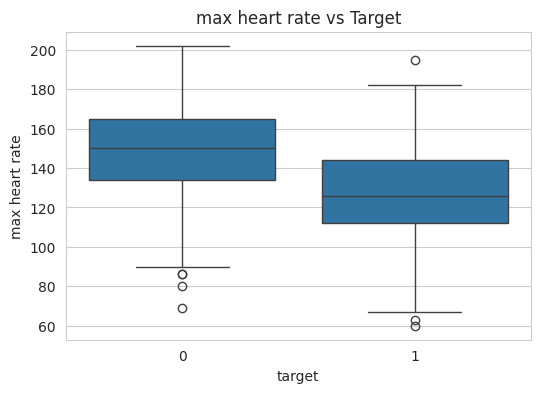

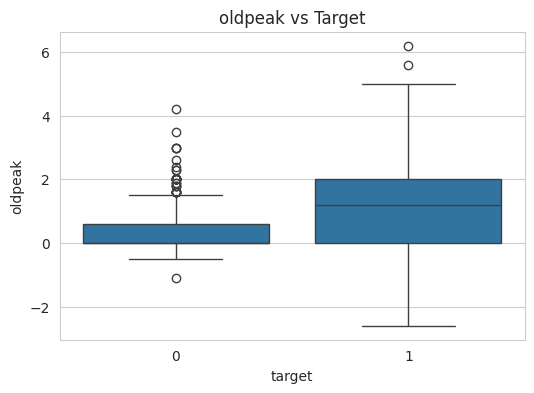

In [23]:
# ============================================================
# 5. Exploratory Data Analysis
# ============================================================

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df)
plt.title("Target Variable Distribution")
plt.show()

print("\nTarget counts:")
print(df["target"].value_counts())


# Histograms
df.hist(figsize=(16, 12))
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# Boxplots for selected numeric features
for col in ["age", "cholesterol", "max heart rate", "oldpeak"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="target", y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

In [24]:
# ============================================================
# 6. Prepare Features and Target
# ============================================================

X = df.drop("target", axis=1)
y = df["target"]


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (734, 11)
Test set shape: (184, 11)


In [25]:
# ============================================================
# 7. Automated Feature Selection Procedure
# ============================================================

feature_selector = SelectKBest(score_func=f_classif, k=8)

X_train_selected = feature_selector.fit_transform(X_train, y_train)
X_test_selected = feature_selector.transform(X_test)

selected_features = X.columns[feature_selector.get_support()]

print("\nSelected Features Using Automated SelectKBest:")
print(list(selected_features))

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "ANOVA F-score": feature_selector.scores_
}).sort_values(by="ANOVA F-score", ascending=False)

print("\nFeature Selection Scores:")
print(feature_scores)


Selected Features Using Automated SelectKBest:
['age', 'sex', 'chest pain type', 'fasting blood sugar', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope']

Feature Selection Scores:
                Feature  ANOVA F-score
10             ST slope     387.117087
8       exercise angina     232.371210
2       chest pain type     197.828260
7        max heart rate     145.522825
9               oldpeak     120.977606
1                   sex      62.376915
5   fasting blood sugar      53.682093
0                   age      46.618076
4           cholesterol      45.301259
3          resting bp s       7.704128
6           resting ecg       3.990931


In [27]:
# ============================================================
# 8. Standardization
# ============================================================

"""
Logistic Regression and KNN require scaling because they are sensitive to
feature magnitude. Decision Tree and Random Forest do not require scaling.
"""

scaler = StandardScaler()

X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)



Logistic Regression Results
Accuracy: 0.8695652173913043
              precision    recall  f1-score   support

           0       0.88      0.82      0.85        82
           1       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



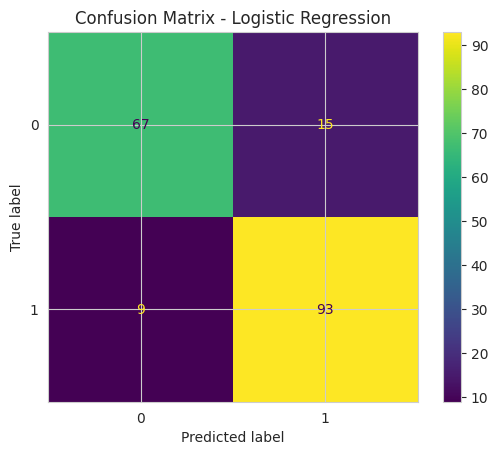

In [28]:
# ============================================================
# 9. Logistic Regression
# ============================================================

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_selected_scaled, y_train)

y_pred_lr = lr.predict(X_test_selected_scaled)

print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

ConfusionMatrixDisplay.from_estimator(lr, X_test_selected_scaled, y_test)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


KNN Results
Accuracy: 0.8641304347826086
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        82
           1       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



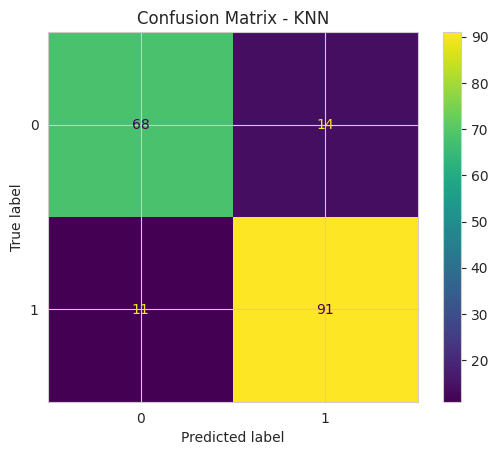

In [29]:

# ============================================================
# 10. KNN Classifier
# ============================================================

knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train_selected_scaled, y_train)

y_pred_knn = knn.predict(X_test_selected_scaled)

print("\nKNN Results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

ConfusionMatrixDisplay.from_estimator(knn, X_test_selected_scaled, y_test)
plt.title("Confusion Matrix - KNN")
plt.show()




Decision Tree Results
Accuracy: 0.7934782608695652
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        82
           1       0.81      0.81      0.81       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184



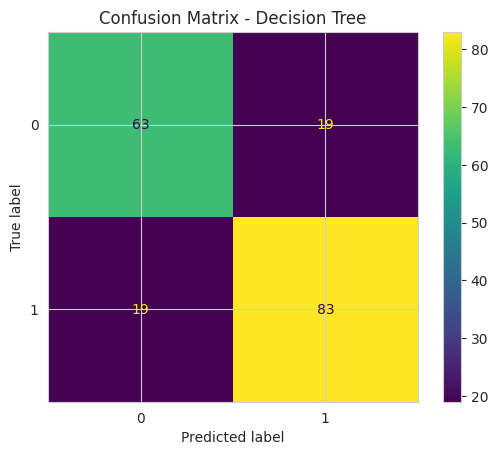

In [30]:

# ============================================================
# 11. Decision Tree
# ============================================================

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

dt.fit(X_train_selected, y_train)

y_pred_dt = dt.predict(X_test_selected)

print("\nDecision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

ConfusionMatrixDisplay.from_estimator(dt, X_test_selected, y_test)
plt.title("Confusion Matrix - Decision Tree")
plt.show()




Random Forest Results
Accuracy: 0.8641304347826086
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        82
           1       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



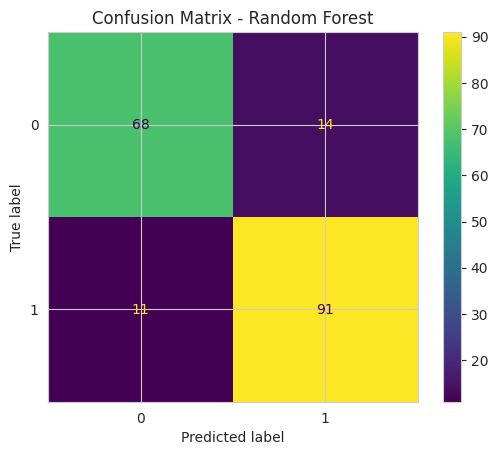

In [31]:

# ============================================================
# 12. Random Forest
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf.fit(X_train_selected, y_train)

y_pred_rf = rf.predict(X_test_selected)

print("\nRandom Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_estimator(rf, X_test_selected, y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()



In [32]:
# ============================================================
# 13. ROC-AUC for Random Forest
# ============================================================

y_prob_rf = rf.predict_proba(X_test_selected)[:, 1]

auc = roc_auc_score(y_test, y_prob_rf)

print("\nRandom Forest ROC-AUC:", auc)




Random Forest ROC-AUC: 0.9233620277379244



Random Forest Feature Importance:
ST slope               0.302389
chest pain type        0.212177
exercise angina        0.137895
max heart rate         0.108970
oldpeak                0.096527
age                    0.067429
sex                    0.039651
fasting blood sugar    0.034961
dtype: float64


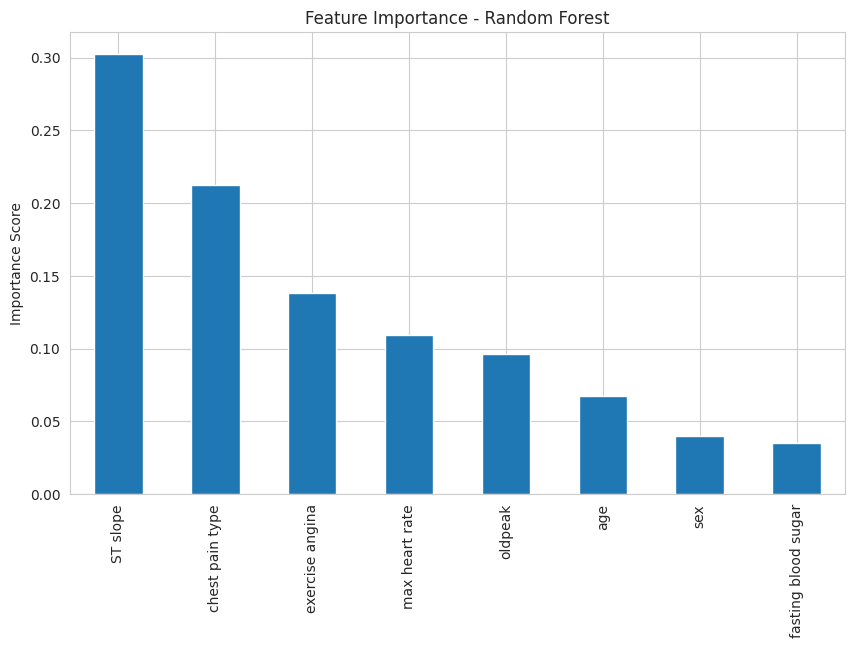

In [34]:
# ============================================================
# 14. Feature Importance from Random Forest
# ============================================================

"""
Feature importance is used here for interpretation only.
The actual automated feature selection was already performed earlier using
SelectKBest.

Random Forest feature importance shows which selected features contributed
most to the Random Forest prediction.
"""

importance = pd.Series(
    rf.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

print("\nRandom Forest Feature Importance:")
print(importance)

plt.figure(figsize=(10, 6))
importance.plot(kind="bar")
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()



In [35]:
# ============================================================
# 15. Hyperparameter Tuning: Tuned Random Forest
# ============================================================

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_selected, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation Score:")
print(grid.best_score_)




Best Parameters:
{'max_depth': 5, 'n_estimators': 50}

Best Cross-Validation Score:
0.8582983878482899



Tuned Random Forest Results on Test Set
Test Set Accuracy: 0.8641304347826086
Cross-Validation Accuracy: 0.8582983878482899
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        82
           1       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



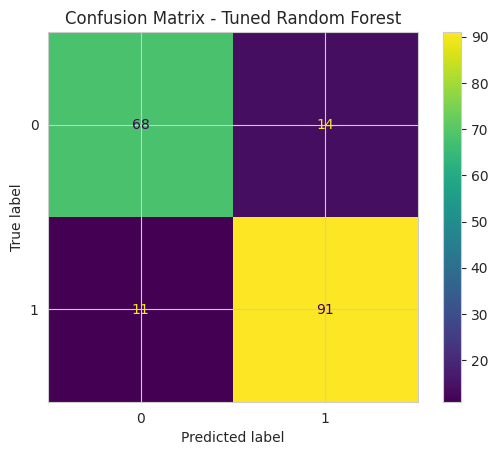

In [36]:
# ============================================================
# 16. Evaluate Tuned Random Forest on Test Set
# ============================================================

"""
Metric Clarification:

grid.best_score_ is the mean cross-validation accuracy from the training set
during GridSearchCV.

The accuracy_score below is the final test-set accuracy using the held-out
test data that was not used during model training or cross-validation.
"""

best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test_selected)

tuned_rf_test_accuracy = accuracy_score(y_test, y_pred_best)

print("\nTuned Random Forest Results on Test Set")
print("Test Set Accuracy:", tuned_rf_test_accuracy)
print("Cross-Validation Accuracy:", grid.best_score_)
print(classification_report(y_test, y_pred_best))

ConfusionMatrixDisplay.from_estimator(best_rf, X_test_selected, y_test)
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()



In [37]:
# ============================================================
# 17. Final Model Comparison Table
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Main Hyperparameters": [
        "max_iter=1000; SelectKBest k=8; standardized",
        "n_neighbors=7; SelectKBest k=8; standardized",
        "max_depth=5; min_samples_split=10; SelectKBest k=8",
        "n_estimators=100; max_depth=5; SelectKBest k=8",
        f"GridSearchCV best params={grid.best_params_}; SelectKBest k=8"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best)
    ]
})

results = results.round(4)

print("\nModel Comparison:")
print(results.to_string(index=False))




Model Comparison:
              Model                                                           Main Hyperparameters  Accuracy  Precision  Recall  F1 Score
Logistic Regression                                   max_iter=1000; SelectKBest k=8; standardized    0.8696     0.8611  0.9118    0.8857
                KNN                                   n_neighbors=7; SelectKBest k=8; standardized    0.8641     0.8667  0.8922    0.8792
      Decision Tree                             max_depth=5; min_samples_split=10; SelectKBest k=8    0.7935     0.8137  0.8137    0.8137
      Random Forest                                 n_estimators=100; max_depth=5; SelectKBest k=8    0.8641     0.8667  0.8922    0.8792
Tuned Random Forest GridSearchCV best params={'max_depth': 5, 'n_estimators': 50}; SelectKBest k=8    0.8641     0.8667  0.8922    0.8792


In [38]:
# ============================================================
# 18. Final Conclusion
# ============================================================

print("""
Final Conclusion:
After applying automated feature selection using SelectKBest, Logistic
Regression achieved the best overall performance with 86.96% accuracy and the
highest F1-score. The results suggest that the selected features were highly
effective for linear classification and preserved most predictive information
for heart disease prediction.

This corrected project applies an automated feature selection method using
SelectKBest with ANOVA F-test. Instead of manually choosing features, the
algorithm selected the top 8 statistically relevant predictors.

All models were trained using the selected features. Logistic Regression and
KNN were trained on standardized selected features, while Decision Tree and
Random Forest were trained on selected features without scaling.

The hyperparameters for each model were clearly listed in the model comparison
table. For the tuned Random Forest, the GridSearchCV cross-validation score and
the final held-out test-set accuracy were reported separately.

Feature importance from Random Forest was used only for interpretation, not as
the main feature selection algorithm.
""")


Final Conclusion:
After applying automated feature selection using SelectKBest, Logistic 
Regression achieved the best overall performance with 86.96% accuracy and the 
highest F1-score. The results suggest that the selected features were highly 
effective for linear classification and preserved most predictive information 
for heart disease prediction.

This corrected project applies an automated feature selection method using
SelectKBest with ANOVA F-test. Instead of manually choosing features, the
algorithm selected the top 8 statistically relevant predictors.

All models were trained using the selected features. Logistic Regression and
KNN were trained on standardized selected features, while Decision Tree and
Random Forest were trained on selected features without scaling.

The hyperparameters for each model were clearly listed in the model comparison
table. For the tuned Random Forest, the GridSearchCV cross-validation score and
the final held-out test-set accuracy were reported